# 05— Moirai (Zero-Shot, 24h-Ahead PV Forecasting)

**Model:** Salesforce Moirai-1.0-R-Small (zero-shot, no fine-tuning)  
**Task:** 24-hour-ahead PV power forecasting at 15-minute resolution (96 steps)  
**Evaluation:**
- Primary: daytime samples (solar elevation > 5°)
- Secondary: all-hours
- Metrics: MAE, RMSE, nRMSE, inference time per 24h window

**Run `01_data_processing.ipynb` first** to generate `data/dataset.csv`.

**Prerequisite:**
```bash
conda create -n moirai_env python=3.11 -y
conda activate moirai_env
pip install uni2ts torch
```

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import time
import os
from tqdm import tqdm

import torch
from uni2ts.model.moirai import MoiraiForecast, MoiraiModule
from gluonts.dataset.common import ListDataset

# ── Device ──
device = 'cpu'
print(f'Device: {device}')

os.makedirs('../results', exist_ok=True)
os.makedirs('../figure',  exist_ok=True)

# ── Config ──
CONTEXT_LENGTH    = 512   # steps fed to model
PREDICTION_LENGTH = 96    # 24h ahead at 15-min resolution
STRIDE            = 96    # step 1 day at a time
NUM_SAMPLES       = 20    # probabilistic samples → take mean
PATCH_SIZE        = 16    # Moirai patch size
SIZE              = 'small'  # 'small' | 'base' | 'large'
MAX_WINDOWS       = None  # set e.g. 10 for a quick smoke-test
MODEL_NAME        = 'Moirai'

Device: cpu


## 1. Load & Prepare Data

In [7]:
df = pd.read_csv('../data/dataset.csv', index_col='timestamp', parse_dates=True)
df.index = df.index.tz_localize('UTC').tz_convert('Europe/Zagreb').tz_localize(None)

agg = {
    'power'             : 'sum',
    'sun_zenith'        : 'mean',
    'sun_azimuth'       : 'mean',
    'temperature'       : 'mean',
    'global_irradiance' : 'mean',
    'direct_irradiance' : 'mean',
    'diffuse_irradiance': 'mean',
}
df_full = df.resample('15min', closed='left', label='left').agg(agg)
df_full['power'] = df_full['power'].fillna(0).clip(lower=0)
wx_cols = [c for c in df_full.columns if c != 'power']
df_full[wx_cols] = df_full[wx_cols].ffill().fillna(0)
df_full['solar_elevation'] = (90 - df_full['sun_zenith']).clip(lower=0)

print(f'15-min grid shape: {df_full.shape}')
print(f'Range: {df_full.index.min()} → {df_full.index.max()}')

15-min grid shape: (171139, 8)
Range: 2018-04-17 07:15:00 → 2023-03-04 23:45:00


In [8]:
test_start = pd.Timestamp('2020-01-01')
test_end   = pd.Timestamp('2020-08-01')

full_series    = df_full['power'].values.astype(np.float32)
test_mask      = (df_full.index >= test_start) & (df_full.index <= test_end)
test_indices   = np.where(test_mask)[0]
test_start_idx = int(test_indices[0])
test_end_idx   = int(test_indices[-1])

start_positions = list(range(test_start_idx, test_end_idx - PREDICTION_LENGTH + 1, STRIDE))
if MAX_WINDOWS:
    start_positions = start_positions[:MAX_WINDOWS]

print(f'Test: {test_start.date()} → {test_end.date()}')
print(f'Rolling windows: {len(start_positions)} × {PREDICTION_LENGTH} steps')

Test: 2020-01-01 → 2020-08-01
Rolling windows: 213 × 96 steps


## 2. Load Moirai Model

In [9]:
print(f'Loading Moirai-1.0-R-{SIZE} ...')
t_load = time.time()

model = MoiraiForecast(
    module=MoiraiModule.from_pretrained(f'Salesforce/moirai-1.0-R-{SIZE}'),
    prediction_length=PREDICTION_LENGTH,
    context_length=CONTEXT_LENGTH,
    patch_size=PATCH_SIZE,
    num_samples=NUM_SAMPLES,
    target_dim=1,
    feat_dynamic_real_dim=0,
    past_feat_dynamic_real_dim=0,
)
predictor = model.create_predictor(batch_size=1, device=device)

print(f'Moirai loaded in {time.time() - t_load:.1f}s')


def predict_moirai(context_array, context_start_time):
    """Run one 96-step Moirai forecast via GluonTS ListDataset."""
    dataset = ListDataset(
        [{
            'start' : pd.Period(context_start_time, freq='15min'),
            'target': context_array.astype(np.float32),
        }],
        freq='15min',
    )
    forecast = next(iter(predictor.predict(dataset)))
    # samples shape: (num_samples, prediction_length) → mean over samples
    return forecast.samples.mean(axis=0)

Loading Moirai-1.0-R-small ...
Moirai loaded in 2.4s


## 3. Rolling 24h-Ahead Evaluation

In [10]:
n = len(start_positions)
all_preds   = np.zeros((n, PREDICTION_LENGTH), dtype=np.float32)
all_actuals = np.zeros((n, PREDICTION_LENGTH), dtype=np.float32)
all_ts      = []
infer_times = []

for w, i in enumerate(tqdm(start_positions, desc='Moirai rolling eval')):
    ctx_start   = max(0, i - CONTEXT_LENGTH)
    context     = full_series[ctx_start:i]
    actual      = full_series[i:i + PREDICTION_LENGTH]
    ts          = df_full.index[i:i + PREDICTION_LENGTH]
    ctx_ts      = df_full.index[ctx_start]  # start timestamp for GluonTS

    t0 = time.time()
    pred = predict_moirai(context, ctx_ts)
    infer_times.append(time.time() - t0)

    all_preds[w]   = pred[:PREDICTION_LENGTH]
    all_actuals[w] = actual
    all_ts.append(ts)

print(f'Done. Avg inference time: {np.mean(infer_times):.3f}s per 24h window')

Moirai rolling eval: 100%|███████████████████| 213/213 [00:03<00:00, 56.85it/s]

Done. Avg inference time: 0.018s per 24h window


## 4. Metrics — Daytime & All-Hours

In [11]:
preds_flat   = np.clip(all_preds.ravel(), 0, None)
actuals_flat = all_actuals.ravel()
ts_flat      = pd.DatetimeIndex(np.concatenate([t.values for t in all_ts]))

solar_elev   = df_full['solar_elevation'].reindex(ts_flat).values
day_mask     = solar_elev > 5

def metrics(y_true, y_pred, label):
    mae   = mean_absolute_error(y_true, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    nrmse = rmse / y_true.max()
    print(f'[{label}]  MAE={mae:.4f}  RMSE={rmse:.4f}  nRMSE={nrmse:.4f}')
    return mae, rmse, nrmse

print(f'\n=== {MODEL_NAME} ===')
mae_d, rmse_d, nrmse_d = metrics(actuals_flat[day_mask], preds_flat[day_mask], 'Daytime')
mae_a, rmse_a, nrmse_a = metrics(actuals_flat,           preds_flat,           'All-hours')

avg_infer = np.mean(infer_times)
print(f'\nAvg inference time per 24h forecast: {avg_infer:.3f}s')
print(f'Daytime samples: {day_mask.sum()} / {len(day_mask)}')


=== Moirai ===
[Daytime]  MAE=0.2223  RMSE=0.3262  nRMSE=0.3795
[All-hours]  MAE=0.2475  RMSE=0.4307  nRMSE=0.5010

Avg inference time per 24h forecast: 0.018s
Daytime samples: 9930 / 20448


## 5. Plots

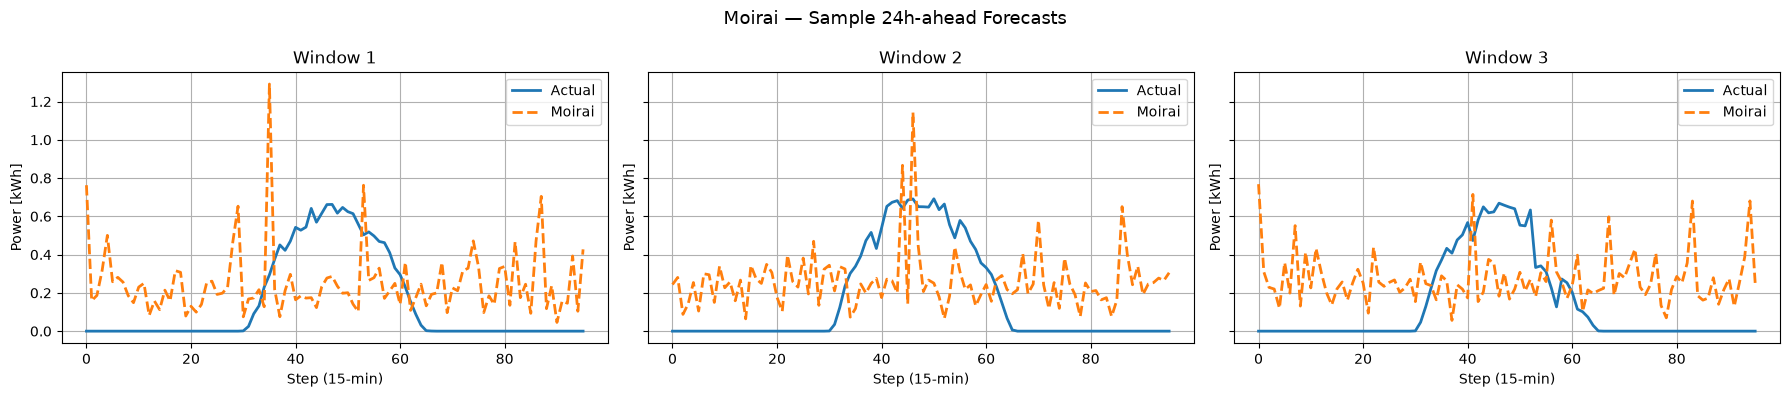

Saved → ../figure/05_moirai_sample_forecasts.png


In [12]:
# ── Sample forecasts ──
sunny_windows = [w for w in range(n) if all_actuals[w].max() > 0.01][:3]

fig, axes = plt.subplots(1, len(sunny_windows), figsize=(6 * len(sunny_windows), 4), sharey=True)
if len(sunny_windows) == 1:
    axes = [axes]

for ax, w in zip(axes, sunny_windows):
    ax.plot(all_actuals[w], label='Actual', linewidth=2)
    ax.plot(all_preds[w],   label='Moirai', linewidth=2, linestyle='--')
    ax.set_title(f'Window {w+1}')
    ax.set_xlabel('Step (15-min)'); ax.set_ylabel('Power [kWh]')
    ax.legend(); ax.grid(True)

plt.suptitle(f'{MODEL_NAME} — Sample 24h-ahead Forecasts', fontsize=13)
plt.tight_layout()
plt.savefig('../figure/05_moirai_sample_forecasts.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → ../figure/05_moirai_sample_forecasts.png')

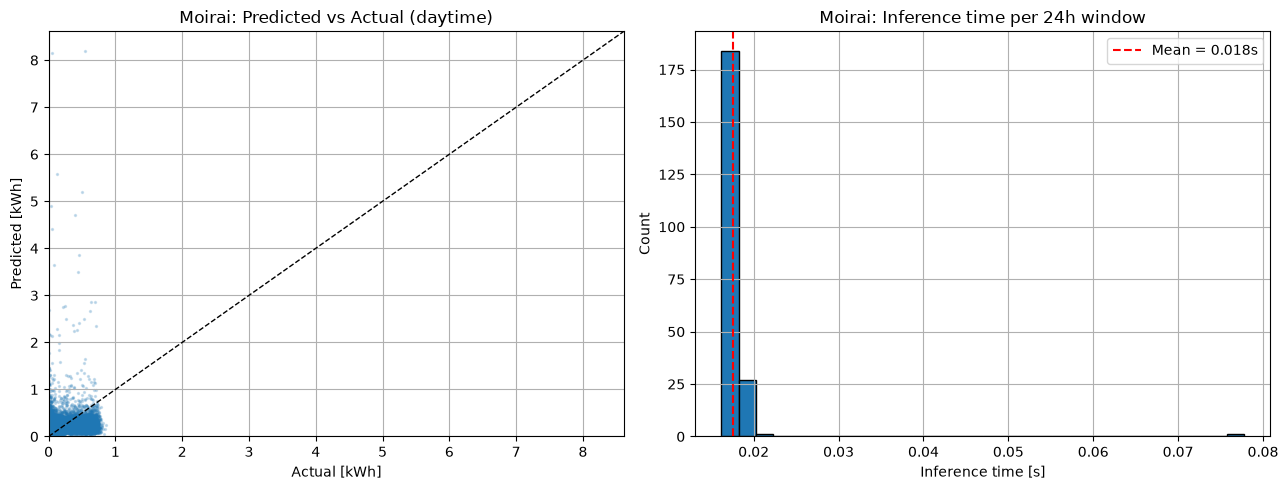

Saved → ../figure/05_moirai_eval.png


In [13]:
# ── Scatter + inference time ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

lim = max(actuals_flat[day_mask].max(), preds_flat[day_mask].max()) * 1.05
axes[0].scatter(actuals_flat[day_mask], preds_flat[day_mask], s=2, alpha=0.2)
axes[0].plot([0, lim], [0, lim], 'k--', linewidth=1)
axes[0].set_xlim(0, lim); axes[0].set_ylim(0, lim)
axes[0].set_xlabel('Actual [kWh]'); axes[0].set_ylabel('Predicted [kWh]')
axes[0].set_title(f'{MODEL_NAME}: Predicted vs Actual (daytime)')
axes[0].grid(True)

axes[1].hist(infer_times, bins=30, edgecolor='black')
axes[1].axvline(avg_infer, color='red', linestyle='--', label=f'Mean = {avg_infer:.3f}s')
axes[1].set_xlabel('Inference time [s]'); axes[1].set_ylabel('Count')
axes[1].set_title(f'{MODEL_NAME}: Inference time per 24h window')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig('../figure/05_moirai_eval.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → ../figure/05_moirai_eval.png')

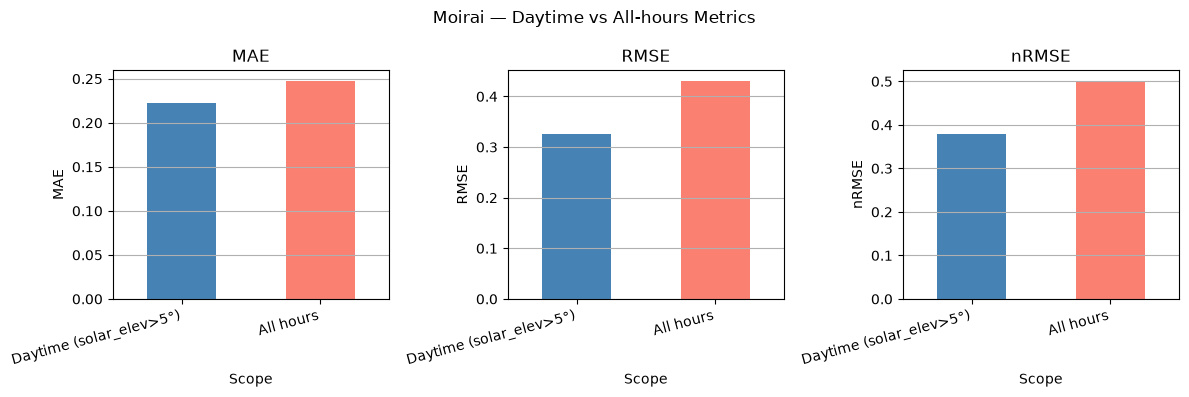

Saved → ../figure/05_moirai_daytime_vs_allhours.png


In [14]:
# ── Daytime vs all-hours bar chart ──
metrics_df = pd.DataFrame({
    'Scope': ['Daytime (solar_elev>5°)', 'All hours'],
    'MAE':   [mae_d,   mae_a],
    'RMSE':  [rmse_d,  rmse_a],
    'nRMSE': [nrmse_d, nrmse_a],
})

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, col in zip(axes, ['MAE', 'RMSE', 'nRMSE']):
    metrics_df.set_index('Scope')[col].plot(kind='bar', ax=ax, color=['steelblue', 'salmon'])
    ax.set_title(col); ax.set_ylabel(col); ax.grid(axis='y')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')

plt.suptitle(f'{MODEL_NAME} — Daytime vs All-hours Metrics', fontsize=12)
plt.tight_layout()
plt.savefig('../figure/05_moirai_daytime_vs_allhours.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → ../figure/05_moirai_daytime_vs_allhours.png')

## 6. Save Results

In [15]:
pd.DataFrame({
    'timestamp'  : ts_flat,
    'actual'     : actuals_flat,
    'moirai'     : preds_flat,
    'solar_elev' : solar_elev,
    'daytime'    : day_mask,
}).to_pickle('../results/moirai_predictions.pkl')
print('Saved → ../results/moirai_predictions.pkl')

Saved → ../results/moirai_predictions.pkl


In [16]:
comp_path = '../results/comparison.csv'
comp_cols = ['Model', 'MAE', 'RMSE', 'nRMSE', 'Train Time', 'Inference Time']

new_rows = pd.DataFrame([
    {'Model': MODEL_NAME,                'MAE': mae_d, 'RMSE': rmse_d, 'nRMSE': nrmse_d,
     'Train Time': 0.0, 'Inference Time': avg_infer},
    {'Model': f'{MODEL_NAME} (all-hrs)', 'MAE': mae_a, 'RMSE': rmse_a, 'nRMSE': nrmse_a,
     'Train Time': 0.0, 'Inference Time': avg_infer},
])

if os.path.exists(comp_path):
    existing = pd.read_csv(comp_path)
    existing = existing[~existing['Model'].isin(new_rows['Model'])]
    combined = pd.concat([existing, new_rows], ignore_index=True)
else:
    combined = new_rows

combined[comp_cols].to_csv(comp_path, index=False)
print(f'Saved → {comp_path}')
print()
print(combined[comp_cols].to_string(index=False))

Saved → ../results/comparison.csv

            Model      MAE     RMSE    nRMSE  Train Time  Inference Time
         LightGBM 0.021175 0.034823 0.040512    0.196141        0.014383
 LightGBM (tuned) 0.020895 0.034539 0.040182   66.418172        0.037487
              MLP 0.020945 0.034464 0.040095    2.954158        0.017441
          Chronos 0.164308 0.231903 0.269790    0.000000        1.622153
Chronos (all-hrs) 0.104663 0.188088 0.218817    0.000000        1.622153
          TimesFM 0.124079 0.178613 0.207794    0.000000        0.077968
TimesFM (all-hrs) 0.062519 0.126753 0.147461    0.000000        0.077968
           Moirai 0.222258 0.326228 0.379526    0.000000        0.017504
 Moirai (all-hrs) 0.247542 0.430665 0.501025    0.000000        0.017504
